In [2]:
from pathlib import Path
import os 
from dataclasses import dataclass
import yaml

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

from src import mod_cog_tasks as mct 
from src import mod_cog_data_utils as mcdu
from src import eg_utils
from src import analysis_utils as au
from src import plot_utils as pu

from train_mod_cog import RNNModel

device = eg_utils.get_device()

In [2]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments 

In [3]:
analysis_dir = Path("/network/projects/_groups/linclab_users/eg/modcog/analysis")
print(os.listdir(analysis_dir))

['seed_5_eg_task_wise_accs.csv', 'seed_5_gd_task_wise_accs.csv', 'seed_6_eg_task_wise_accs.csv', 'seed_6_gd_task_wise_accs.csv', 'seed_7_eg_task_wise_accs.csv', 'seed_7_gd_task_wise_accs.csv', 'seed_8_eg_task_wise_accs.csv', 'seed_8_gd_task_wise_accs.csv', 'seed_9_eg_task_wise_accs.csv', 'seed_9_gd_task_wise_accs.csv']


In [4]:
# csv files are generated by analysis_1_solutions.sh
gd_dfs = []
eg_dfs = []
# load dfs into lists
for f in analysis_dir.glob("*.csv"):
    f = analysis_dir / f
    if "gd" in f.name:
        gd_dfs.append(pd.read_csv(f))
    if "eg" in f.name:
        eg_dfs.append(pd.read_csv(f))

In [5]:
gd_dfs[0].head()

,model_0_0-49.pt,model_0_0-99.pt,model_25_0-302.pt,model_35_0-365.pt,model_45_0-412.pt,model_55_0-453.pt,model_65_0-502.pt,model_75_0-565.pt,model_85_0-676.pt,model_95_1-374.pt,model_6.pt
0,0.061688,0.061688,0.602842,0.841621,0.682606,0.977658,1.000000,1.000000,1.000000,1.000000,1.0
1,0.062479,0.051144,0.487099,0.560486,0.693102,0.710303,0.802618,0.820770,0.823416,0.986043,1.0
2,0.064381,0.064381,0.223385,0.461500,0.391658,0.841015,0.940110,0.982456,1.000000,1.000000,1.0
3,0.064631,0.064631,0.018822,0.163246,0.404619,0.395230,0.478387,0.812756,1.000000,1.000000,1.0
4,0.066702,0.054528,0.056208,0.195599,0.293305,0.365565,0.378976,0.629171,0.899590,1.000000,1.0


In [6]:
gd_dfs[1].head()

,model_0_0-49.pt,model_0_0-99.pt,model_25_0-306.pt,model_35_0-395.pt,model_45_0-428.pt,model_55_0-465.pt,model_65_0-515.pt,model_75_0-569.pt,model_85_0-687.pt,model_95_1-359.pt,model_6.pt
0,0.061688,0.061688,0.711144,0.646059,0.911100,0.961071,0.999684,1.000000,1.000000,1.000000,1.0
1,0.062479,0.054433,0.507568,0.644015,0.707164,0.788357,0.797393,0.829460,0.842533,0.984654,1.0
2,0.064381,0.064381,0.274592,0.309522,0.655535,0.853410,0.960320,1.000000,1.000000,1.000000,1.0
3,0.064631,0.064631,0.000000,0.151760,0.312731,0.382215,0.526406,0.850926,1.000000,1.000000,1.0
4,0.066702,0.058854,0.047637,0.166406,0.342988,0.358178,0.335876,0.668855,0.912196,0.998504,1.0


In [7]:
len(gd_dfs)
gd_df = gd_dfs[0]

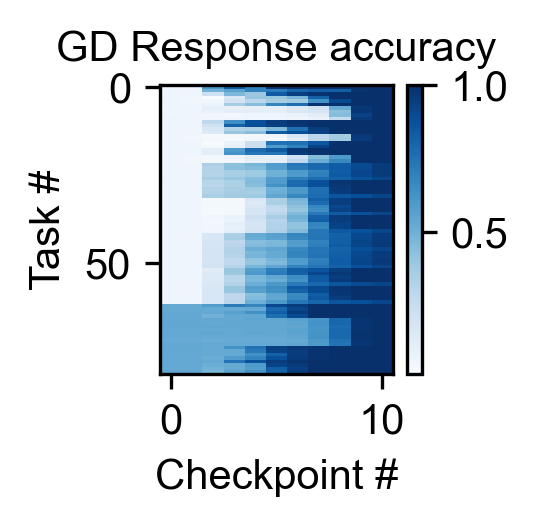

In [8]:
plt.figure(figsize=(1.25,1.25), dpi=300)
plt.title("GD Response accuracy", fontsize=10)
plt.xlabel("Checkpoint #", )
plt.ylabel("Task #")
plt.imshow(gd_df, aspect="auto", cmap="Blues")
plt.colorbar()

#plt.savefig("figs/fig1d_taskwise.pdf", bbox_inches="tight", transparent=True)
plt.savefig("figs/fig1/fig1d_gd_taskwise.pdf", bbox_inches="tight", transparent=True)

In [9]:
len(eg_dfs)
eg_df = eg_dfs[0]

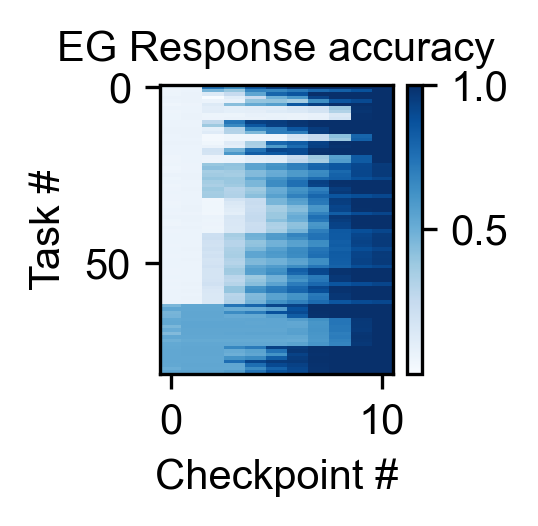

In [10]:
plt.figure(figsize=(1.25,1.25), dpi=300)
plt.title("EG Response accuracy")
plt.xlabel("Checkpoint #")
plt.ylabel("Task #")
plt.imshow(eg_df, aspect="auto", cmap="Blues")
plt.colorbar()

plt.savefig("figs/fig1/fig1d_eg_taskwise.pdf", bbox_inches="tight", transparent=True)

In [11]:
# calc cosine similarity between eg_df and gd_df columns
# loop over seeds


n_seeds = len(gd_dfs)
n_checkpoints = gd_df.shape[1]
cosine_sims_algwise = np.zeros((n_seeds, n_checkpoints))

for seed_i in range(len(gd_dfs)):
    gd_df = gd_dfs[seed_i]
    eg_df = eg_dfs[seed_i]

    for col_idx in range(gd_df.shape[1]):
        gd_col = gd_df.iloc[:,col_idx]
        eg_col = eg_df.iloc[:,col_idx]
        cosine_sim = np.dot(eg_col, gd_col)/(np.linalg.norm(eg_col)*np.linalg.norm(gd_col))
        cosine_sims_algwise[seed_i, col_idx] = cosine_sim

In [12]:
cosine_sims_algwise.shape

(5, 11)

(11,)


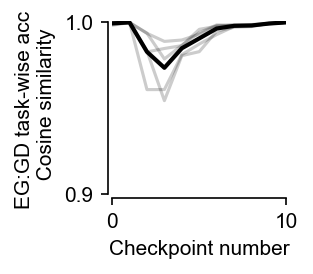

In [15]:
mean_sim = cosine_sims_algwise.mean(axis=0)
std_sim = cosine_sims_algwise.std(axis=0)
print(std_sim.shape)
plt.figure(figsize=(1.5,1.5), dpi=150)

plt.plot(cosine_sims_algwise.T, "k", alpha=0.2)
plt.plot(cosine_sims_algwise.mean(axis=0), "k", lw=2)

#plt.fill_between(np.arange(0,mean_sim.shape[0]), 
                #  mean_sim-std_sim, mean_sim+std_sim, 
                #  color="k", alpha=0.2)


plt.ylim(0.9,1.001 )
plt.yticks([0.9, 1.0])
plt.xlim(0,10)
plt.xticks([0,10])
sns.despine(offset=2, trim=True)
plt.xlabel("Checkpoint number", )
plt.ylabel("EG:GD task-wise acc \n Cosine similarity",)

plt.savefig("figs/fig1/fig1d_taskwise_comp.pdf", bbox_inches="tight", transparent=True)
# plt.savefig("figs/fig1d_taskwise_comp.png", bbox_inches="tight", transparent=True)

In [3]:
%load_ext autoreload
%autoreload 2

In [7]:
results_dir =  Path("/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined")

In [9]:
#os.listdir(results_dir)

In [10]:
# drop larger weights for now, comparing 1e-7 eg, 1e-6 gd
exp_names = []
for exp_name in os.listdir(results_dir):
    if exp_name.startswith("eg"):
        if "1e-07" in exp_name:exp_names.append(exp_name)
    elif exp_name.startswith("gd"):
        if "1e-06" in exp_name:exp_names.append(exp_name)
exp_names

['eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_normal_a1.0_lrsched_custom_loss',
 'gd_N2500_lr0.1_m0.925_wd1e-06_mxgn2.0_init_uniform_a1.0_lrsched_custom_loss']

In [11]:
# reformat exp_name for use as a key
def format_exp_as_key(exp_name):
    s = exp_name[:2]
    if "log_normal" in exp_name:
        s += "_log_normal"
    elif "normal" in exp_name:
        s += "_normal"
    elif "uniform" in exp_name:
        s += "_uniform"
    return s

exp_folders = au.DotDict({format_exp_as_key(f):results_dir/f for f in exp_names})
list(exp_folders.keys())

['eg_log_normal',
 'eg_normal',
 'eg_uniform',
 'gd_log_normal',
 'gd_normal',
 'gd_uniform']

In [21]:
# reformat exp_names above for use as a key for results dict
# for example: eg_log_normal from eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss
exp_folders = au.DotDict({au.format_exp_as_key(f):results_dir/f for f in exp_names})
results_dict = au.load_results(exp_folders, verbose=True)
# Stack results across all seeds for each experiment
for exp_name in results_dict.keys():
    results_dict[exp_name] = au.concat_seed_results(results_dict[exp_name])

 : loaded 5 results from 5
 : loaded 5 results from 5
 : loaded 5 results from 5
 : loaded 5 results from 5
 : loaded 5 results from 5
 : loaded 5 results from 5


In [22]:
# Add colours to exps
# https://www.datylon.com/blog/data-visualization-for-colorblind-readers
results_dict.eg_normal.c = "#fec615" # golden yellow
results_dict.eg_uniform.c = "green" #ff9408" # tangerine
results_dict.eg_log_normal.c = "#f05039" # orangey red

results_dict.gd_log_normal.c = "#1f449c" # blue
results_dict.gd_normal.c = "#8af1fe"
results_dict.gd_uniform.c = "#9e43a2"

# Begin new code 

(differs below from Fig1a notebook)

In [23]:
# we are interested in the decc acc checkpoints
results_dict.eg_log_normal.seed_5.dec_acc_ckpts

[PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/dec_acc_ckpts/model_0_0-99.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/dec_acc_ckpts/model_0_0-49.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/dec_acc_ckpts/model_25_0-382.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/dec_acc_ckpts/model_35_0-448.pt'),
 PosixPath('/network/projects/_groups/linclab_users/eg/modcog/exp8_final_combined/eg_N2500_lr3.5_m0.925_wd1e-07_mxgn2.0_init_log_normal1.5_a1.0_lrsched_custom_loss/seed_5/dec_acc_c

In [24]:
@dataclass
class DataConfig:
    batch_size: int = 512
    seq_len:int = 350
    copy_data_to_device_mem: bool = False
    num_workers: int = 0
    pin_memory: bool = True

cfg = DataConfig()

# load data
# change to linclab path
data_dir = Path("/network/scratch/c/cornforj/eg_paper/mod_cog_data_v2")
print(os.listdir(data_dir)[:])

loaders = {}
for split in ["train", "val", "test"]:
    dataset = mcdu.ModCogDataset(data_dir, split=split, in_memory=cfg.copy_data_to_device_mem)
    loaders[split] = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=split=="train",
                                num_workers=cfg.num_workers, pin_memory=cfg.pin_memory)

['mod_cog_train_x.memmap', 'mod_cog_train_y.memmap', 'mod_cog_train.npz', 'mod_cog_val_x.memmap', 'mod_cog_val_y.memmap', 'mod_cog_val.npz', 'mod_cog_test_x.memmap', 'mod_cog_test_y.memmap', 'mod_cog_test.npz', 'slurm-4893722.out']
Loading train memmap files /network/scratch/c/cornforj/eg_paper/mod_cog_data_v2
Loading val memmap files /network/scratch/c/cornforj/eg_paper/mod_cog_data_v2
Loading test memmap files /network/scratch/c/cornforj/eg_paper/mod_cog_data_v2


In [25]:
def get_model(cfg):
    input_size = 115 # hardcoded for now, but should make responsive to data
    output_size = 17
    model = RNNModel(input_size, cfg.model.hidden_size, output_size)
    if cfg.update_alg == "eg":
        eg_utils.set_split_bias(model)
        print("Setting split bias")
    return model

gd_model = get_model(results_dict.gd_log_normal.seed_7.cfg)
eg_model = get_model(results_dict.eg_log_normal.seed_7.cfg)

print(eg_model)
print(gd_model)

Setting split bias
RNNModel(
  (rnn): SplitBiasRNNCell(
    (base_layer): RNNCell(115, 2500, nonlinearity=relu)
  )
  (fc): SplitBias(
    (base_layer): Linear(in_features=2500, out_features=17, bias=True)
  )
)
RNNModel(
  (rnn): RNNCell(115, 2500, nonlinearity=relu)
  (fc): Linear(in_features=2500, out_features=17, bias=True)
)


In [26]:
def load_ckpt(model, ckpt_path):
    state_dict = torch.load(ckpt_path)
    model.load_state_dict(state_dict)
    return model

def add_one_hot_encoding(inputs):
    task_rules = inputs[:,:,-1]
    one_hot_rule_inputs = torch.nn.functional.one_hot(task_rules.long(), num_classes=82).float()
    inputs = torch.cat([inputs[:,:,:-1], one_hot_rule_inputs], dim=-1)
    return inputs

In [27]:
@torch.no_grad()
def compute_acc_with_fixation_unit(outputs, labels, dec_mask):
    choices = torch.argmax(outputs, dim=-1)
    labels_for_full_acc = 1 + labels
    labels_for_full_acc[~dec_mask] = 0

    acc = torch.eq(choices, labels_for_full_acc).type(torch.float32).mean().item()
    dec_acc = torch.eq(choices[dec_mask], labels_for_full_acc[dec_mask]).type(torch.float32).mean().item()

    return acc, dec_acc

In [28]:
def get_subtasks_performance(model, loader, device, n_subtasks=82, debug=False):
    """
    If debug = True only iterates over 4 batches
    """
    task_rule_labels = torch.from_numpy(np.arange(n_subtasks)).to(device)
    task_wise_accs = []
    task_wise_proportions = []
    dec_accs = []
    for i, (inputs, labels) in enumerate(loader):
        print(f"{i}/{len(loader)}", end="\r")
        inputs, labels = inputs.to(device), labels.to(device)
        input_subtask_labels = inputs[:,:,-1].clone() # store the tensor of non one hot encoded task labels 
        inputs = add_one_hot_encoding(inputs).to(device)
        labels = labels.to(device).long()

        outputs = model(inputs)
        choices = torch.argmax(outputs, dim=-1)
        
        dec_mask = inputs[:,:,0] == 0 # fixation/decision period mask, fix=1, dec=0
        labels_for_full_acc = 1 + labels
        labels_for_full_acc[~dec_mask] = 0

        acc = torch.eq(choices, labels_for_full_acc).type(torch.float32).mean().item()
        #dec_acc = torch.eq(choices[dec_mask], labels_for_full_acc[dec_mask]).type(torch.float32).mean().item()

        dec_correct_choices = torch.eq(choices[dec_mask],labels_for_full_acc[dec_mask]).type(torch.float32)
        dec_acc = dec_correct_choices.mean()
        dec_accs.append(dec_acc.item())
        print(acc, dec_accs)

        subtask_labels_dec_period = input_subtask_labels[dec_mask]
        subtask_labels_bool_array = task_rule_labels[:, None] == subtask_labels_dec_period[None,:]
        # this creates a bool array of shape (n_subtasks, batch_size*seq_len) 
        # each row is a bool array of subtask label == task_label (over all time steps and batch examples)
        
        # broadcast the dec period correct choices array over and mult by subtasks_bool_array
        task_wise_dec_correct_choices = subtask_labels_bool_array*dec_correct_choices[None,:]

        total_taskwise_examples = subtask_labels_bool_array.sum(axis=1)
        total_taskwise_correct = task_wise_dec_correct_choices.sum(axis=1)
        
        task_wise_acc = total_taskwise_correct/total_taskwise_examples
        task_wise_accs.append(task_wise_acc)

        # also store the relative proportion of each task for taking a weighted average
        # to confirm code results in the same overall accuracy as dec acc
        task_wise_proportion = total_taskwise_examples/total_taskwise_examples.sum()
        task_wise_proportions.append(task_wise_proportion)
        
        if debug and i ==4: break
        
    print(np.mean(dec_accs), "is mean dec acc")
    # stack the task_wise lists into n_subtasks x n_batches
    task_wise_accs = torch.stack(task_wise_accs, dim=1)
    task_wise_proportions = torch.stack(task_wise_proportions, dim=1)

    task_wise_accs = task_wise_accs.mean(dim=1) 
    task_wise_proportions = task_wise_proportions.mean(dim=1)
    assert np.allclose((task_wise_accs@task_wise_proportions).detach().cpu().numpy(), np.mean(dec_accs), atol=1e-3)

    return task_wise_accs, task_wise_proportions


def get_taskwise_performance_over_checkpoints(model, dataloader, ckpts, device, debug):
    ckpt_task_wise_accs_dict = {}
    for model_ckpt in ckpts:
        print(model_ckpt.name)
        model = load_ckpt(model, model_ckpt)
        model = model.to(device)
        task_wise_accs, task_wise_proportions = get_subtasks_performance(model, dataloader, device, debug=debug)

        #print(task_wise_proportions)
        ckpt_task_wise_accs_dict[model_ckpt.name] = task_wise_accs.detach().cpu().numpy()
    return ckpt_task_wise_accs_dict


In [30]:
dec_acc_ckpts = sorted(results_dict.gd_uniform.seed_7.dec_acc_ckpts[:]) + [results_dict.gd_uniform.seed_7.epoch_ckpts[-1]]
gd_task_wise_accs = get_taskwise_performance_over_checkpoints(gd_model, loaders["val"], dec_acc_ckpts, device, debug=1)

model_0_0-49.pt
0.6934040188789368 [0.17175252735614777]
0.6948828101158142 [0.17175252735614777, 0.1694771647453308]
0.6959654092788696 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494]
0.6934319138526917 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745]
0.6952734589576721 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745, 0.17333172261714935]
0.17148371934890747 is mean dec acc
model_0_0-99.pt
0.7116740942001343 [0.17084342241287231]
0.7135937213897705 [0.17084342241287231, 0.16823190450668335]
0.7151171565055847 [0.17084342241287231, 0.16823190450668335, 0.17249952256679535]
0.7122935056686401 [0.17084342241287231, 0.16823190450668335, 0.17249952256679535, 0.1679452359676361]
0.7138839364051819 [0.17084342241287231, 0.16823190450668335, 0.17249952256679535, 0.1679452359676361, 0.1722634732723236]
0.17035671174526215 is mean dec acc
model_25_0-288.pt
0.695128321647644 [0.23485824465751648]
0.698331475257873

In [31]:
gd_df = pd.DataFrame(gd_task_wise_accs)

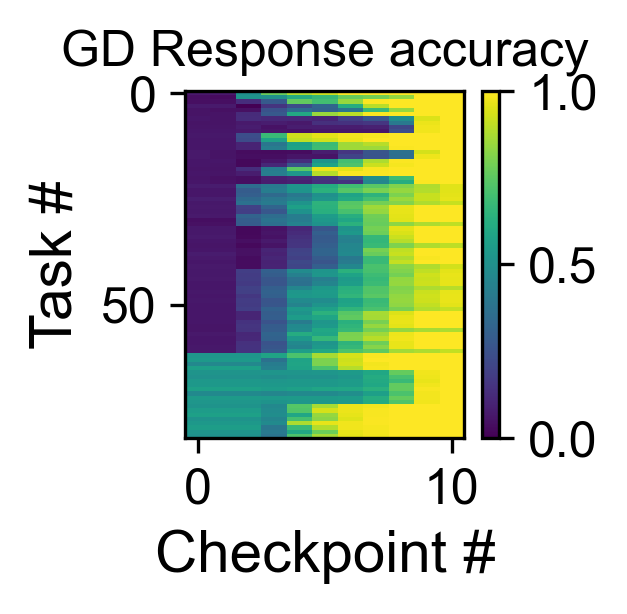

In [33]:
plt.figure(figsize=(1.5,1.5), dpi=300)
plt.title("GD Response accuracy")
plt.xlabel("Checkpoint #")
plt.ylabel("Task #")
plt.imshow(gd_df, aspect="auto")
plt.colorbar()

plt.savefig("figs/fig1d_taskwise.pdf", bbox_inches="tight", transparent=True)
plt.savefig("figs/fig1d_taskwise.png", bbox_inches="tight", transparent=True)

In [34]:
eg_dec_acc_ckpts = sorted(results_dict.eg_log_normal.seed_7.dec_acc_ckpts[:]) + [results_dict.eg_log_normal.seed_7.epoch_ckpts[-1]]
eg_task_wise_accs = get_taskwise_performance_over_checkpoints(eg_model, loaders["val"], eg_dec_acc_ckpts, device, debug=1)

model_0_0-49.pt
0.14654017984867096 [0.17175252735614777]
0.1442689746618271 [0.17175252735614777, 0.1694771647453308]
0.14922991394996643 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494]
0.1460770070552826 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745]
0.1484430730342865 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745, 0.17333172261714935]
0.17148371934890747 is mean dec acc
model_0_0-99.pt
0.6970200538635254 [0.17175252735614777]
0.6985658407211304 [0.17175252735614777, 0.1694771647453308]
0.7000892758369446 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494]
0.6971819400787354 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745]
0.6992577910423279 [0.17175252735614777, 0.1694771647453308, 0.17365631461143494, 0.1692008674144745, 0.17333172261714935]
0.17148371934890747 is mean dec acc
model_25_0-368.pt
0.7561941742897034 [0.2525600790977478]
0.7593247890472412

In [35]:
eg_df = pd.DataFrame(eg_task_wise_accs)

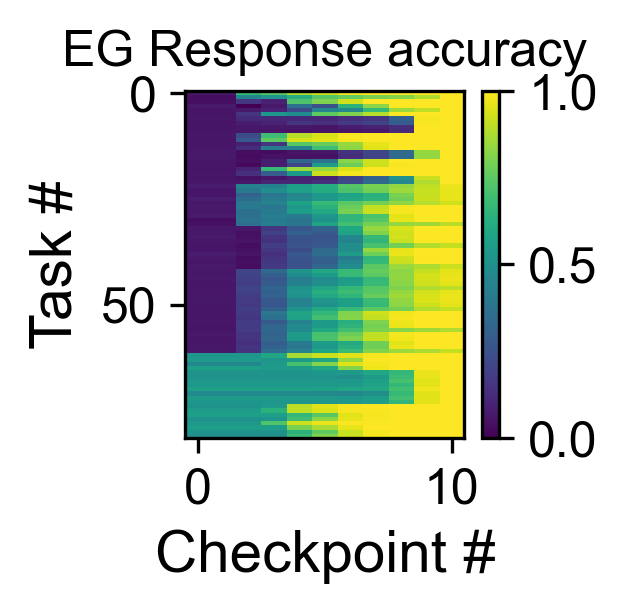

In [37]:
plt.figure(figsize=(1.5,1.5), dpi=300)
plt.title("EG Response accuracy")
plt.xlabel("Checkpoint #")
plt.ylabel("Task #")
plt.imshow(eg_df, aspect="auto")
plt.colorbar()

plt.savefig("figs/fig1d_taskwise_eg.pdf", bbox_inches="tight", transparent=True)
plt.savefig("figs/fig1d_taskwise_eg.png", bbox_inches="tight", transparent=True)

In [38]:
# calc cosine similarity between eg_df and gd_df columns

cosine_sims_algwise = []
for col_idx in range(gd_df.shape[1]):
    gd_col = gd_df.iloc[:,col_idx]
    eg_col = eg_df.iloc[:,col_idx]
    cosine_sim = np.dot(eg_col, gd_col)/(np.linalg.norm(eg_col)*np.linalg.norm(gd_col))
    cosine_sims_algwise.append(cosine_sim)

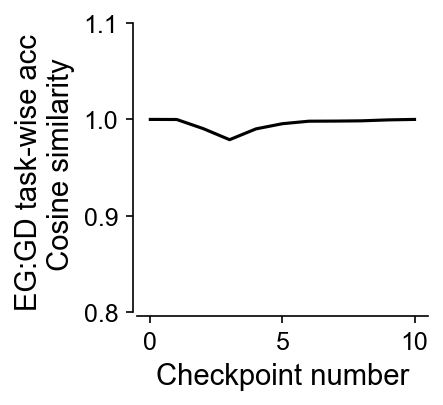

In [39]:
plt.figure(figsize=(2.5,2.5), dpi=150)
plt.plot(cosine_sims_algwise, "k")
plt.ylim(0.8,1.1 )
sns.despine(offset=2, trim=False)
plt.xlabel("Checkpoint number")
plt.ylabel("EG:GD task-wise acc \n Cosine similarity")

plt.savefig("figs/fig1d_taskwise_comp.pdf", bbox_inches="tight", transparent=True)
plt.savefig("figs/fig1d_taskwise_comp.png", bbox_inches="tight", transparent=True)